In [4]:
# !pip install tensorflow

In [5]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU
from tensorflow.random import set_seed

from sklearn.model_selection import train_test_split


In [6]:
# Load dataset
dataset = pd.read_csv(
    "Mastercard_stock_history.csv",
    index_col="Date",
    parse_dates=["Date"]
)

# Drop useless columns
dataset = dataset.drop(["Dividends", "Stock Splits"], axis=1)

# Show data
dataset

,Open,High,Low,Close,Volume
Date,,,,,
2006-05-25 00:00:00-04:00,3.677800,4.202548,3.668674,4.197985,395343000
2006-05-26 00:00:00-04:00,4.225363,4.265517,4.025502,4.100336,103044000
2006-05-30 00:00:00-04:00,4.103990,4.104902,3.910517,4.015467,49898000
2006-05-31 00:00:00-04:00,4.047406,4.139579,4.047406,4.101250,30002000
2006-06-01 00:00:00-04:00,4.100334,4.389630,4.097596,4.335786,62344000
...,...,...,...,...,...
2025-03-12 00:00:00-04:00,530.510010,532.710022,519.260010,524.640015,2810800
2025-03-13 00:00:00-04:00,524.500000,528.530029,517.710022,519.830017,2375800
2025-03-14 00:00:00-04:00,522.599976,528.409973,520.950012,527.640015,2369500


In [7]:
# take only High column values
data = dataset["High"].values

# convert 1D array into 2D array because scaler needs 2D input
data = data.reshape(-1,1)


In [8]:
data

array([[  4.2025483 ],
       [  4.26551693],
       [  4.10490213],
       ...,
       [528.40997314],
       [533.47998047],
       [532.59002686]], shape=(4733, 1))

In [9]:

from tensorflow.keras.layers import Dense, SimpleRNN


# scale data
sc = MinMaxScaler()
data = sc.fit_transform(data)
data

array([[3.07779089e-04],
       [4.16682654e-04],
       [1.38901078e-04],
       ...,
       [9.06918877e-01],
       [9.15687400e-01],
       [9.14148235e-01]], shape=(4733, 1))

In [10]:

# empty list for input sequences
X = []

# empty list for output values
y = []

# use previous 60 days data to predict next day
n_steps = 60

# loop starts from day 60 to last row
for i in range(n_steps, len(data)):
    
    # store previous 60 values in X
    X.append(data[i-n_steps:i])
    
    # store next value in y
    y.append(data[i])

# convert list into numpy array
X = np.array(X)

# convert list into numpy array
y = np.array(y)


In [11]:
X

array([[[3.07779089e-04],
        [4.16682654e-04],
        [1.38901078e-04],
        ...,
        [1.78826128e-03],
        [1.60043914e-03],
        [1.50731421e-03]],

       [[4.16682654e-04],
        [1.38901078e-04],
        [1.98875126e-04],
        ...,
        [1.60043914e-03],
        [1.50731421e-03],
        [1.80720222e-03]],

       [[1.38901078e-04],
        [1.98875126e-04],
        [6.31334123e-04],
        ...,
        [1.50731421e-03],
        [1.80720222e-03],
        [1.79931114e-03]],

       ...,

       [[9.16401938e-01],
        [9.16954529e-01],
        [9.11393807e-01],
        ...,
        [9.23591178e-01],
        [9.14355765e-01],
        [9.07126513e-01]],

       [[9.16954529e-01],
        [9.11393807e-01],
        [9.20632975e-01],
        ...,
        [9.14355765e-01],
        [9.07126513e-01],
        [9.06918877e-01]],

       [[9.11393807e-01],
        [9.20632975e-01],
        [9.06972794e-01],
        ...,
        [9.07126513e-01],
        [9.0691

In [12]:
y

array([[0.0018072 ],
       [0.00179931],
       [0.00183877],
       ...,
       [0.90691888],
       [0.9156874 ],
       [0.91414823]], shape=(4673, 1))

In [13]:

# train test split (time series, no shuffle)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)
X_train

array([[[3.07779089e-04],
        [4.16682654e-04],
        [1.38901078e-04],
        ...,
        [1.78826128e-03],
        [1.60043914e-03],
        [1.50731421e-03]],

       [[4.16682654e-04],
        [1.38901078e-04],
        [1.98875126e-04],
        ...,
        [1.60043914e-03],
        [1.50731421e-03],
        [1.80720222e-03]],

       [[1.38901078e-04],
        [1.98875126e-04],
        [6.31334123e-04],
        ...,
        [1.50731421e-03],
        [1.80720222e-03],
        [1.79931114e-03]],

       ...,

       [[6.10669705e-01],
        [6.09351165e-01],
        [6.04161289e-01],
        ...,
        [6.19916339e-01],
        [6.30189869e-01],
        [6.34099694e-01]],

       [[6.09351165e-01],
        [6.04161289e-01],
        [6.07373281e-01],
        ...,
        [6.30189869e-01],
        [6.34099694e-01],
        [6.34032081e-01]],

       [[6.04161289e-01],
        [6.07373281e-01],
        [6.19409634e-01],
        ...,
        [6.34099694e-01],
        [6.3403

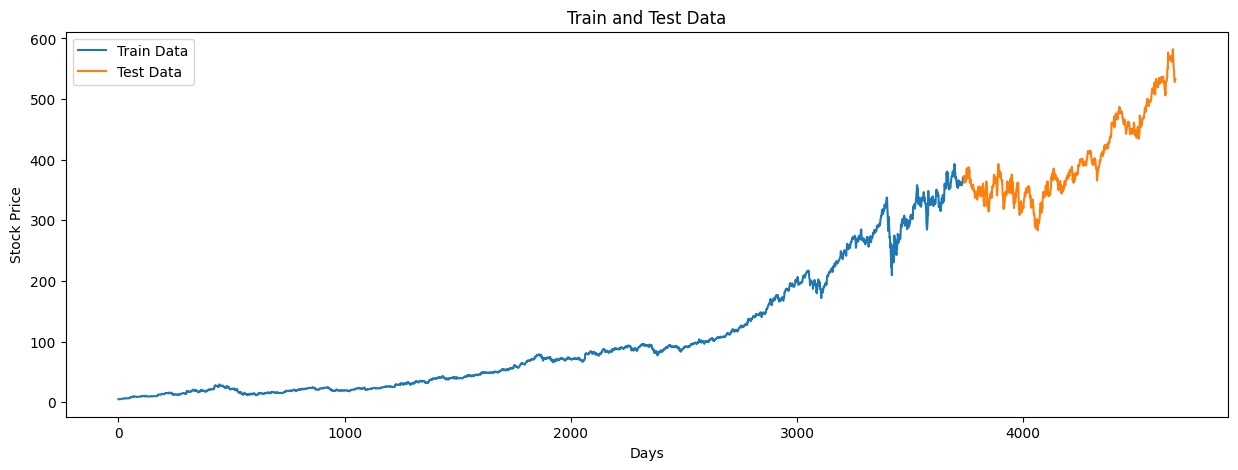

In [14]:

# convert scaled values back for plotting
train_plot = sc.inverse_transform(y_train)
test_plot = sc.inverse_transform(y_test)

# plot train and test data first
plt.figure(figsize=(15,5))

# plot training data
plt.plot(range(len(train_plot)), train_plot, label="Train Data")

# plot testing data after train data
plt.plot(
    range(len(train_plot), len(train_plot)+len(test_plot)),
    test_plot,
    label="Test Data"
)

# title
plt.title("Train and Test Data")

# labels
plt.xlabel("Days")
plt.ylabel("Stock Price")

# legend
plt.legend()

# show graph
plt.show()

In [15]:

# build SIMPLE RNN model (from scratch style)
model = Sequential()

# RNN layer (this is the simplest recurrent network)
model.add(SimpleRNN(50, activation="tanh", input_shape=(60, 1)))

# output layer
model.add(Dense(1))

# compile model
model.compile(optimizer="adam", loss="mse")
model.summary()

c:\Users\Moazzam\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

### (1+50+1)×50=2600

In [16]:

# train model
model.fit(X_train, y_train, epochs=20, batch_size=32)

Epoch 1/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - loss: 9.0754e-04
Epoch 2/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - loss: 9.5694e-05
Epoch 3/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 7.2422e-05
Epoch 4/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 7.9167e-05
Epoch 5/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - loss: 5.5233e-05
Epoch 6/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 4.8905e-05
Epoch 7/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 7.0116e-05
Epoch 8/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 4.1667e-05
Epoch 9/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 4.8255e-05
Epoch 10/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 4.1295e-05
Epoch 11/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 3.5340e-05
Epoch 12/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 3.0642e-05
Epoch 13/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 3.1466e-05
Epoch 14/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - los

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step


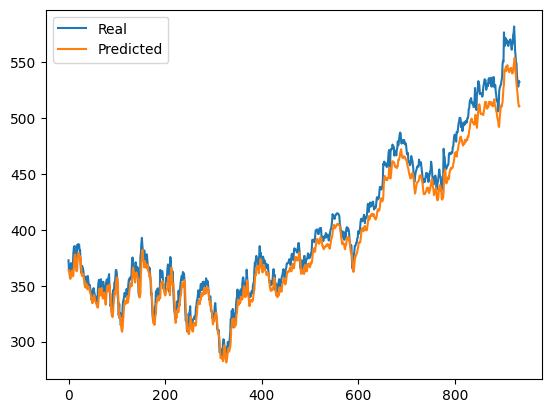

RMSE: 12.413485459530946


In [17]:


# prediction
pred = model.predict(X_test)

# convert back to original scale
pred = sc.inverse_transform(pred)
real = sc.inverse_transform(y_test)

# plot results
plt.plot(real, label="Real")
plt.plot(pred, label="Predicted")
plt.legend()
plt.show()

# error
rmse = np.sqrt(mean_squared_error(real, pred))
print("RMSE:", rmse)

### LSTM

In [18]:

# ---------------- LSTM MODEL ----------------
model = Sequential()
model.add(LSTM(125, activation="tanh", input_shape=(60,1)))
model.add(Dense(1))

model.compile(optimizer="RMSprop", loss="mse")
model.summary()

c:\Users\Moazzam\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 125)            │        63,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           126 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,626 (248.54 KB)

 Trainable params: 63,626 (248.54 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:

model.fit(X_train, y_train, epochs=50, batch_size=32)


Epoch 1/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 11s 64ms/step - loss: 0.0013
Epoch 2/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 9s 78ms/step - loss: 2.9778e-04
Epoch 3/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - loss: 2.1603e-04
Epoch 4/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - loss: 1.8612e-04
Epoch 5/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 8s 66ms/step - loss: 1.5417e-04
Epoch 6/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - loss: 1.3681e-04
Epoch 7/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - loss: 1.3930e-04
Epoch 8/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - loss: 1.2377e-04
Epoch 9/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - loss: 1.0342e-04
Epoch 10/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - loss: 1.0704e-04
Epoch 11/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - loss: 1.0011e-04
Epoch 12/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 9s 77ms/step - loss: 9.4373e-05
Epoch 13/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - loss: 9.1421e-05
Epoch 14/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - loss: 8

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step


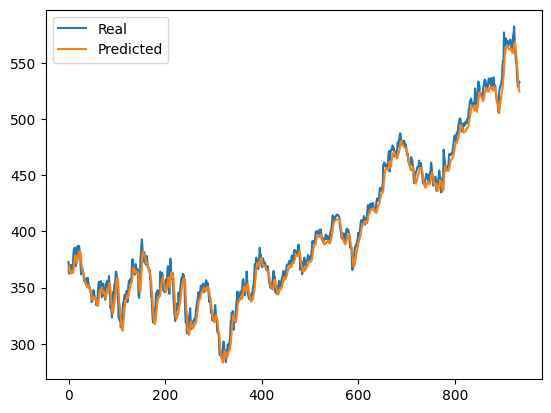

RMSE: 8.260161898239058


In [20]:

# Prediction
pred = model.predict(X_test)
pred = sc.inverse_transform(pred)

real = sc.inverse_transform(y_test)

# Plot
plt.plot(real, label="Real")
plt.plot(pred, label="Predicted")
plt.legend()
plt.show()

# RMSE
rmse = np.sqrt(mean_squared_error(real, pred))
print("RMSE:", rmse)

In [21]:

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score


In [22]:
y_test

array([[0.63775555],
       [0.62162582],
       [0.61956088],
       [0.62132112],
       [0.62856505],
       [0.63321962],
       [0.6330672 ],
       [0.62101068],
       [0.62590792],
       [0.63029672],
       [0.64820773],
       [0.65666345],
       [0.65949313],
       [0.65976427],
       [0.63458385],
       [0.63119469],
       [0.63848114],
       [0.64180246],
       [0.66152661],
       [0.65879847],
       [0.66284826],
       [0.65683288],
       [0.66193324],
       [0.6522068 ],
       [0.65386736],
       [0.63131331],
       [0.61875708],
       [0.62333219],
       [0.6293308 ],
       [0.62763634],
       [0.62467084],
       [0.61994305],
       [0.60852205],
       [0.60899652],
       [0.60952191],
       [0.61062335],
       [0.61269068],
       [0.60330304],
       [0.600219  ],
       [0.60686147],
       [0.6134024 ],
       [0.60713262],
       [0.60001564],
       [0.59713487],
       [0.59974451],
       [0.59496607],
       [0.58959438],
       [0.587

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step


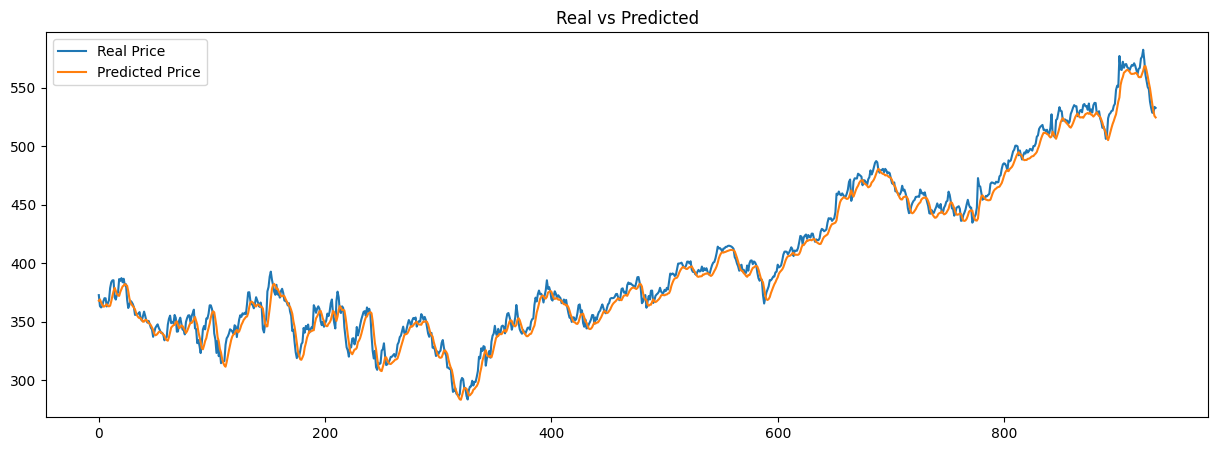

MSE  : 68.23027458512027
RMSE : 8.260161898239058
MAE  : 6.552644307998069
R2   : 0.9853929579974231
MAPE : 1.6708656257222312 %


In [23]:

# ---------------- PREDICTION ----------------
pred = model.predict(X_test)

# inverse scaling
pred = sc.inverse_transform(pred)
real = sc.inverse_transform(y_test)


# ---------------- PLOT RESULT ----------------
plt.figure(figsize=(15,5))

plt.plot(real, label="Real Price")
plt.plot(pred, label="Predicted Price")

plt.title("Real vs Predicted")
plt.legend()
plt.show()


# ---------------- CALCULATE METRICS ----------------

# Mean Squared Error
mse = mean_squared_error(real, pred)

# Root Mean Squared Error
rmse = np.sqrt(mse)

# Mean Absolute Error
mae = mean_absolute_error(real, pred)

# R2 Score
r2 = r2_score(real, pred)

# Mean Absolute Percentage Error
mape = np.mean(np.abs((real - pred) / real)) * 100


# ---------------- PRINT METRICS ----------------
print("MSE  :", mse)
print("RMSE :", rmse)
print("MAE  :", mae)
print("R2   :", r2)
print("MAPE :", mape,"%")

In [24]:
pred

array([[368.00116],
       [369.09293],
       [366.85687],
       [364.54276],
       [362.97614],
       [363.09805],
       [364.1349 ],
       [364.99814],
       [363.5025 ],
       [363.1784 ],
       [363.7457 ],
       [367.49207],
       [372.02087],
       [376.02737],
       [379.03146],
       [376.54254],
       [373.6259 ],
       [372.4743 ],
       [372.1574 ],
       [375.53604],
       [377.77176],
       [380.2121 ],
       [380.92444],
       [382.23972],
       [381.36404],
       [380.81967],
       [376.20398],
       [370.20898],
       [366.38705],
       [364.72296],
       [363.43073],
       [362.16333],
       [360.54697],
       [357.3999 ],
       [355.18777],
       [353.77094],
       [353.09885],
       [353.17035],
       [351.7038 ],
       [350.10263],
       [350.17252],
       [351.57047],
       [351.65173],
       [350.4512 ],
       [348.98267],
       [348.335  ],
       [347.0327 ],
       [345.1004 ],
       [343.19492],
       [339.83496],


In [26]:
# # save full model (architecture + weights + optimizer)
# model.save("stock_rnn_model.h5")
# #or 
# from tensorflow.keras.models import load_model

# model = load_model("stock_rnn_model.h5")

# Metrics Summary

# MSE
# Average squared error
# Lower is better

# RMSE
# Square root of MSE
# Shows error in real stock price units
# Lower is better

# MAE
# Average absolute error
# Easy to understand
# Lower is better

# R2 Score
# Measures how well model fits data
# Best = 1
# Closer to 1 is better

# MAPE
# Percentage error
# Lower is better
# Below 5% is good

# Best for Stock Prediction
# RMSE
# MAE
# MAPE
# R2
```
